In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!find /content/drive/MyDrive -iname "*.zip"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/QR_Phishing_CNN_Detection-BCAmain.zip
/content/drive/MyDrive/QR_Phishing_Dataset.zip


In [ ]:
!unzip -q "/content/drive/MyDrive/QR_Phishing_Dataset.zip" -d /content/data
!ls /content/data

'Dataset of 1000 Images of Malicious and Benign QR codes 2025'


In [ ]:
!ls /content/data/*

'1000 QR Images of Malicious and Benign QR codes.rar'


In [ ]:
import os
from collections import Counter

for root, dirs, files in os.walk("/content/data"):
    depth = root.count(os.sep) - "/content/data".count(os.sep)
    if depth > 3:
        continue
    exts = Counter(os.path.splitext(f)[1].lower() for f in files)
    print("  " * depth + os.path.basename(root) + "/", "| folders:", len(dirs), "| files:", dict(exts))

In [ ]:
import os, zipfile
from google.colab import drive

drive.mount('/content/drive')

ZIP = "/content/drive/MyDrive/QR_Phishing_Dataset.zip"
print("Zip maujood hai?", os.path.exists(ZIP))

if os.path.exists(ZIP):
    print("Zip size (MB):", round(os.path.getsize(ZIP) / 1e6, 1))
    with zipfile.ZipFile(ZIP) as z:
        names = z.namelist()
        print("Zip ke andar total files:", len(names))
        print("Pehli 10 entries:")
        for n in names[:10]:
            print("  ", n)
        z.extractall("/content/data")
    print("Unzip ho gaya. /content/data me:", os.listdir("/content/data"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zip maujood hai? True
Zip size (MB): 0.6
Zip ke andar total files: 1
Pehli 10 entries:
   Dataset of 1000 Images of Malicious and Benign QR codes 2025/1000 QR Images of Malicious and Benign QR codes.rar
Unzip ho gaya. /content/data me: ['Dataset of 1000 Images of Malicious and Benign QR codes 2025']


In [ ]:
import os

RAR = "/content/data/Dataset of 1000 Images of Malicious and Benign QR codes 2025/1000 QR Images of Malicious and Benign QR codes.rar"
print("Rar maujood hai?", os.path.exists(RAR))

!apt-get install -y -qq unrar > /dev/null 2>&1
!mkdir -p /content/qr_raw
!unrar x -o+ -inul "$RAR" /content/qr_raw

# Ab dekho andar kya hai
from collections import Counter
for root, dirs, files in os.walk("/content/qr_raw"):
    depth = root.count(os.sep) - "/content/qr_raw".count(os.sep)
    if depth > 3:
        continue
    exts = Counter(os.path.splitext(f)[1].lower() for f in files)
    print("  " * depth + os.path.basename(root) + "/", "| folders:", len(dirs), "| files:", dict(exts))

Rar maujood hai? True
qr_raw/ | folders: 1 | files: {}
  1000 QR Images of Malicious and Benign QR codes 2025/ | folders: 2 | files: {}
    benign_qr_images_500/ | folders: 0 | files: {'.png': 500}
    malicious_qr_images_500/ | folders: 0 | files: {'.png': 500}


In [ ]:
!cp -r "/content/qr_raw/1000 QR Images of Malicious and Benign QR codes 2025" /content/drive/MyDrive/dataset
!ls /content/drive/MyDrive/dataset
!ls /content/drive/MyDrive/dataset/benign_qr_images_500 | wc -l
!ls /content/drive/MyDrive/dataset/malicious_qr_images_500 | wc -l

benign_qr_images_500  malicious_qr_images_500
500
500


In [ ]:
import os, random, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

DATA_DIR = "/content/drive/MyDrive/dataset"
DIST_DIR = "/content/dataset_distorted"
IMG_SIZE = (128, 128)
BATCH = 32
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
print(os.listdir(DATA_DIR))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
['benign_qr_images_500', 'malicious_qr_images_500']


In [ ]:
# 1. Data load karna (80% train, 20% validation)
def load_data(path):
    train = tf.keras.utils.image_dataset_from_directory(
        path, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH, label_mode="binary")
    val = tf.keras.utils.image_dataset_from_directory(
        path, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH, label_mode="binary")
    AUTO = tf.data.AUTOTUNE
    return train.cache().prefetch(AUTO), val.cache().prefetch(AUTO), train.class_names

train_ds, val_ds, class_names = load_data(DATA_DIR)
print("Classes:", class_names)

# 2. Model banane ka function
def build_model(filters=(16, 32, 64), dropout=0.3):
    m = models.Sequential()
    m.add(layers.Input(shape=IMG_SIZE + (3,)))
    m.add(layers.Rescaling(1./255))
    for f in filters:
        m.add(layers.Conv2D(f, 3, activation="relu", padding="same"))
        m.add(layers.MaxPooling2D())
    m.add(layers.Flatten())
    m.add(layers.Dense(128, activation="relu"))
    m.add(layers.Dropout(dropout))
    m.add(layers.Dense(1, activation="sigmoid"))
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

# 3. Experiment chalane ka function + graph
results = []
trained_models = {}

def run_experiment(run_id, filters, dropout, epochs):
    print(f"\n===== Run {run_id}: filters={filters}, dropout={dropout}, epochs={epochs} =====")
    model = build_model(filters, dropout)
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=2)
    results.append({
        "Run": run_id,
        "Filters": "-".join(map(str, filters)),
        "Dropout": dropout,
        "Epochs": epochs,
        "Val Acc (final)": round(hist.history["val_accuracy"][-1], 4),
        "Val Acc (best)": round(max(hist.history["val_accuracy"]), 4),
    })
    trained_models[run_id] = model
    return hist

def plot_hist(hist, title):
    plt.figure(figsize=(9, 3))
    plt.subplot(1, 2, 1); plt.plot(hist.history["accuracy"], label="train"); plt.plot(hist.history["val_accuracy"], label="val"); plt.title(title + " accuracy"); plt.legend()
    plt.subplot(1, 2, 2); plt.plot(hist.history["loss"], label="train"); plt.plot(hist.history["val_loss"], label="val"); plt.title(title + " loss"); plt.legend()
    plt.show()

print("Setup ho gaya")

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Classes: ['benign_qr_images_500', 'malicious_qr_images_500']
Setup ho gaya



===== Run 1: filters=(16, 32, 64), dropout=0.3, epochs=15 =====
Epoch 1/15
25/25 - 9s - 347ms/step - accuracy: 0.7375 - loss: 0.5787 - val_accuracy: 0.7650 - val_loss: 0.5060
Epoch 2/15
25/25 - 0s - 12ms/step - accuracy: 0.7850 - loss: 0.4791 - val_accuracy: 0.7650 - val_loss: 0.5114
Epoch 3/15
25/25 - 0s - 11ms/step - accuracy: 0.8100 - loss: 0.4364 - val_accuracy: 0.8100 - val_loss: 0.4695
Epoch 4/15
25/25 - 0s - 12ms/step - accuracy: 0.8338 - loss: 0.3901 - val_accuracy: 0.8550 - val_loss: 0.4309
Epoch 5/15
25/25 - 0s - 11ms/step - accuracy: 0.8637 - loss: 0.3528 - val_accuracy: 0.8800 - val_loss: 0.3907
Epoch 6/15
25/25 - 0s - 11ms/step - accuracy: 0.8813 - loss: 0.3123 - val_accuracy: 0.8750 - val_loss: 0.3650
Epoch 7/15
25/25 - 0s - 12ms/step - accuracy: 0.8875 - loss: 0.2915 - val_accuracy: 0.8550 - val_loss: 0.3897
Epoch 8/15
25/25 - 0s - 11ms/step - accuracy: 0.8950 - loss: 0.2852 - val_accuracy: 0.8500 - val_loss: 0.4326
Epoch 9/15
25/25 - 0s - 12ms/step - accuracy: 0.9087 -

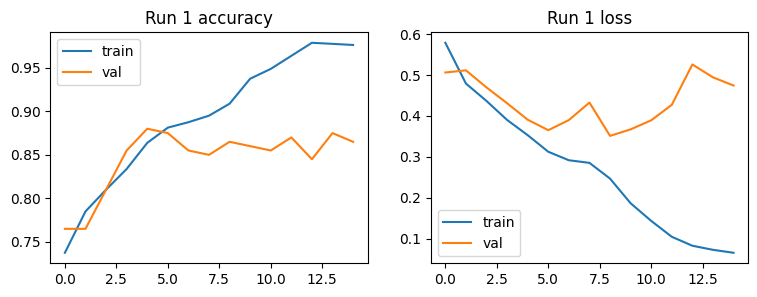

In [ ]:
h1 = run_experiment(1, (16, 32, 64), 0.3, 15)
plot_hist(h1, "Run 1")

In [ ]:
h2 = run_experiment(2, (16, 32, 64), 0.3, 10)   # epochs kam
h3 = run_experiment(3, (16, 32, 64), 0.3, 25)   # epochs zyada
h4 = run_experiment(4, (32, 64, 128), 0.3, 15)  # bade filters
h5 = run_experiment(5, (16, 32, 64), 0.5, 15)   # zyada dropout
h6 = run_experiment(6, (32, 64, 128), 0.5, 15)  # dono

df = pd.DataFrame(results)
display(df)
print(df.to_markdown(index=False))
df.to_csv("experiment_results.csv", index=False)


===== Run 2: filters=(16, 32, 64), dropout=0.3, epochs=10 =====
Epoch 1/10
25/25 - 5s - 219ms/step - accuracy: 0.6637 - loss: 0.6823 - val_accuracy: 0.7650 - val_loss: 0.5402
Epoch 2/10
25/25 - 0s - 12ms/step - accuracy: 0.7837 - loss: 0.5415 - val_accuracy: 0.7600 - val_loss: 0.5224
Epoch 3/10
25/25 - 0s - 10ms/step - accuracy: 0.7900 - loss: 0.5005 - val_accuracy: 0.7600 - val_loss: 0.4993
Epoch 4/10
25/25 - 0s - 12ms/step - accuracy: 0.7875 - loss: 0.4645 - val_accuracy: 0.7850 - val_loss: 0.4794
Epoch 5/10
25/25 - 0s - 10ms/step - accuracy: 0.8025 - loss: 0.4189 - val_accuracy: 0.8500 - val_loss: 0.4295
Epoch 6/10
25/25 - 0s - 10ms/step - accuracy: 0.8525 - loss: 0.3583 - val_accuracy: 0.8650 - val_loss: 0.4143
Epoch 7/10
25/25 - 0s - 10ms/step - accuracy: 0.8788 - loss: 0.3178 - val_accuracy: 0.8700 - val_loss: 0.3869
Epoch 8/10
25/25 - 0s - 12ms/step - accuracy: 0.8888 - loss: 0.2896 - val_accuracy: 0.8500 - val_loss: 0.3938
Epoch 9/10
25/25 - 0s - 10ms/step - accuracy: 0.9075 -

,Run,Filters,Dropout,Epochs,Val Acc (final),Val Acc (best)
0,1,16-32-64,0.3,15,0.865,0.880
1,2,16-32-64,0.3,10,0.870,0.870
2,3,16-32-64,0.3,25,0.865,0.885
3,4,32-64-128,0.3,15,0.875,0.880
4,5,16-32-64,0.5,15,0.860,0.875
5,6,32-64-128,0.5,15,0.875,0.885


|   Run | Filters   |   Dropout |   Epochs |   Val Acc (final) |   Val Acc (best) |
|------:|:----------|----------:|---------:|------------------:|-----------------:|
|     1 | 16-32-64  |       0.3 |       15 |             0.865 |            0.88  |
|     2 | 16-32-64  |       0.3 |       10 |             0.87  |            0.87  |
|     3 | 16-32-64  |       0.3 |       25 |             0.865 |            0.885 |
|     4 | 32-64-128 |       0.3 |       15 |             0.875 |            0.88  |
|     5 | 16-32-64  |       0.5 |       15 |             0.86  |            0.875 |
|     6 | 32-64-128 |       0.5 |       15 |             0.875 |            0.885 |


Best run: 4 (32, 64, 128) 0.3 15
Distorted images bani: 1000


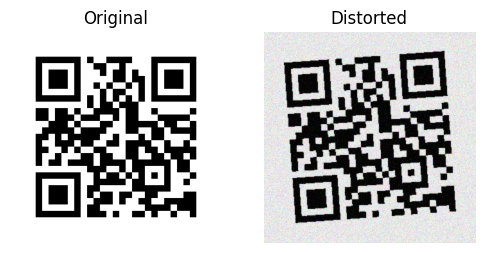

In [ ]:
# 1. Best model chuno aur save karo
best_row = df.loc[df["Val Acc (final)"].idxmax()]
best_id = int(best_row["Run"])
best_filters = tuple(int(x) for x in best_row["Filters"].split("-"))
best_dropout = float(best_row["Dropout"])
best_epochs = int(best_row["Epochs"])
clean_model = trained_models[best_id]
clean_model.save("/content/clean_model.keras")
print("Best run:", best_id, best_filters, best_dropout, best_epochs)

# 2. distort() function
def distort(img):
    img = img.convert("RGB")
    img = img.rotate(random.uniform(-15, 15), fillcolor=(255, 255, 255))
    img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))
    arr = np.asarray(img).astype(np.float32)
    arr = arr * random.uniform(0.8, 1.2)
    arr = arr + np.random.normal(0, 15, arr.shape)
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

# 3. Distorted dataset banao (same folder names, same file names)
random.seed(SEED); np.random.seed(SEED)
if os.path.exists(DIST_DIR):
    shutil.rmtree(DIST_DIR)
count = 0
for cls in class_names:
    os.makedirs(os.path.join(DIST_DIR, cls), exist_ok=True)
    for fname in sorted(os.listdir(os.path.join(DATA_DIR, cls))):
        img = Image.open(os.path.join(DATA_DIR, cls, fname))
        distort(img).save(os.path.join(DIST_DIR, cls, fname))
        count += 1
print("Distorted images bani:", count)

# 4. Ek original aur distorted image saath me dekho
cls0 = class_names[0]
f0 = sorted(os.listdir(os.path.join(DATA_DIR, cls0)))[0]
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1); plt.imshow(Image.open(os.path.join(DATA_DIR, cls0, f0))); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(Image.open(os.path.join(DIST_DIR, cls0, f0))); plt.title("Distorted"); plt.axis("off")
plt.show()

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.

TEST A
Clean model -> clean val acc     : 0.8750
Clean model -> distorted val acc : 0.6800
Accuracy drop: 19.50 percentage points

TEST B: distorted data par retrain
Epoch 1/15
25/25 - 9s - 356ms/step - accuracy: 0.5400 - loss: 0.7311 - val_accuracy: 0.4950 - val_loss: 0.6619
Epoch 2/15
25/25 - 1s - 22ms/step - accuracy: 0.6925 - loss: 0.5945 - val_accuracy: 0.7650 - val_loss: 0.5177
Epoch 3/15
25/25 - 0s - 19ms/step - accuracy: 0.7700 - loss: 0.4986 - val_accuracy: 0.7700 - val_loss: 0.5067
Epoch 4/15
25/25 - 0s - 19ms/step - accuracy: 0.7937 - loss: 0.4735 - val_accuracy: 0.7650 - val_loss: 0.5792
Epoch 5/15
25/25 - 0s - 19ms/step - accuracy: 0.8062 - loss: 0.4442 - val_accuracy: 0.7800 - val_loss: 0.5482
Epoch 6/15
25/25 - 0s - 19ms/step - accuracy: 0.8288 - loss: 0.4308 - val_accuracy: 0.7850 - val_loss: 0.5043
Epoch 7/15
25/25 - 0s - 19ms

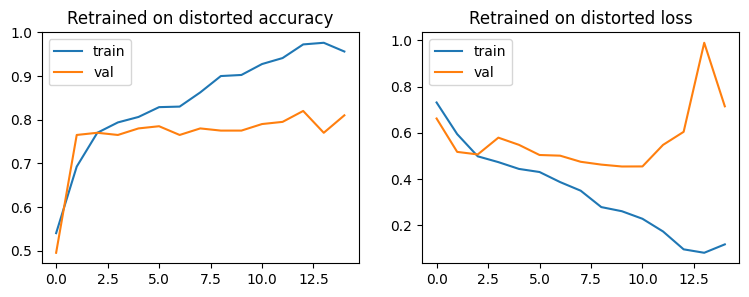


 | Model             | Test on       |   Accuracy |
|:------------------|:--------------|-----------:|
| Clean-trained     | Clean val     |      0.875 |
| Clean-trained     | Distorted val |      0.68  |
| Distorted-trained | Distorted val |      0.81  |
| Distorted-trained | Clean val     |      0.805 |


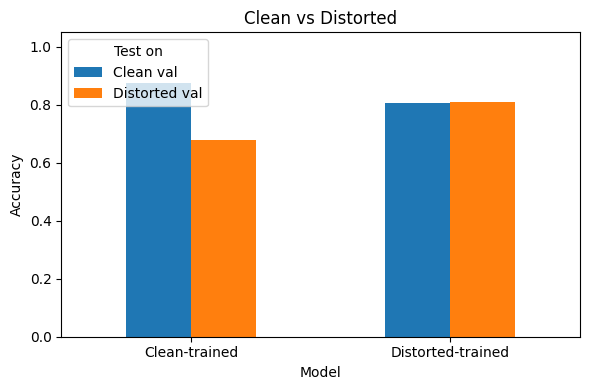

In [ ]:
# distorted data load karo (train/val split same rahega)
dist_train_ds, dist_val_ds, _ = load_data(DIST_DIR)

# ---- TEST A: clean model ko distorted par test karo (retrain nahi) ----
clean_on_clean = clean_model.evaluate(val_ds, verbose=0)[1]
clean_on_dist  = clean_model.evaluate(dist_val_ds, verbose=0)[1]
print(f"\nTEST A")
print(f"Clean model -> clean val acc     : {clean_on_clean:.4f}")
print(f"Clean model -> distorted val acc : {clean_on_dist:.4f}")
print(f"Accuracy drop: {(clean_on_clean - clean_on_dist)*100:.2f} percentage points")

# ---- TEST B: distorted data par retrain ----
print("\nTEST B: distorted data par retrain")
dist_model = build_model(best_filters, best_dropout)
hist_d = dist_model.fit(dist_train_ds, validation_data=dist_val_ds, epochs=best_epochs, verbose=2)
plot_hist(hist_d, "Retrained on distorted")

dist_on_dist  = dist_model.evaluate(dist_val_ds, verbose=0)[1]
dist_on_clean = dist_model.evaluate(val_ds, verbose=0)[1]

# ---- Final comparison table ----
cmp = pd.DataFrame([
    {"Model": "Clean-trained",     "Test on": "Clean val",     "Accuracy": round(clean_on_clean, 4)},
    {"Model": "Clean-trained",     "Test on": "Distorted val", "Accuracy": round(clean_on_dist, 4)},
    {"Model": "Distorted-trained", "Test on": "Distorted val", "Accuracy": round(dist_on_dist, 4)},
    {"Model": "Distorted-trained", "Test on": "Clean val",     "Accuracy": round(dist_on_clean, 4)},
])
print("\n", cmp.to_markdown(index=False))
cmp.to_csv("clean_vs_distorted.csv", index=False)

cmp.pivot(index="Model", columns="Test on", values="Accuracy").plot(kind="bar", figsize=(6, 4), ylim=(0, 1.05), rot=0)
plt.ylabel("Accuracy"); plt.title("Clean vs Distorted"); plt.tight_layout()
plt.savefig("clean_vs_distorted.png", dpi=150); plt.show()

In [ ]:
clean_model.save("qr_cnn_clean_model.keras")
dist_model.save("qr_cnn_distorted_model.keras")

from google.colab import files
for f in ["qr_cnn_clean_model.keras", "qr_cnn_distorted_model.keras",
          "experiment_results.csv", "clean_vs_distorted.csv", "clean_vs_distorted.png"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>